# SEE Detector - V12 Machine Learning Pipeline
Notebook ini berisi tahapan ekstraksi fitur perilaku (agnostik), pelatihan model Random Forest, Cross-Validation, dan evaluasi hasil menggunakan plot Confusion Matrix dan ROC.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Mengatur tampilan plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


## 1. Load Data dan Ekstraksi Fitur Dinamis
Mengekstrak tanda-tanda kebocoran data (HTML, URL, Kredensial, Tracker) dari *Payload Dinamis* menggunakan *Regular Expressions* (Regex).

In [ ]:
# Load dataset mentah hasil agregasi
df = pd.read_csv('results/dataset_v12_raw.csv')
print(f"Total data: {len(df)} (Aman: {len(df[df['label']==0])}, Rentan: {len(df[df['label']==1])})")

# Fungsi Ekstraksi Perilaku Agnostik (Rule-based)
import re

def is_reversed_b64(payload):
    p = str(payload).strip()
    if len(p) > 20 and p.startswith('==') and not ' ' in p: return 1
    if len(p) > 20 and p.startswith('91Hbs') and not ' ' in p: return 1
    return 0

def has_url_in_payload(payload):
    p = str(payload)
    if re.search(r'(https?://|www\.)[a-zA-Z0-9\-\.]+\.[a-zA-Z]{2,}', p, re.IGNORECASE): return 1
    return 0

def has_html_in_payload(payload):
    p = str(payload)
    if re.search(r'<html>|<body|<tbody|<div|<script|<iframe|<td', p, re.IGNORECASE): return 1
    return 0

def has_sensitive_in_payload(payload):
    p = str(payload)
    if re.search(r'cookie|token|password|session|username|document\.location|localStorage|keys|exfil|PIN|OTP|secret', p, re.IGNORECASE): return 1
    if re.search(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', p): return 1
    return 0

def is_telemetry_leak(url, payload):
    u = str(url).lower()
    p = str(payload).lower()
    if re.search(r'(/track|/log|/collect|/metrics|/telemetry|/pixel)', u):
        if has_sensitive_in_payload(p) or has_url_in_payload(p): return 1
    return 0

# (Catatan: Fitur-fitur di bawah ini sudah diekstraksi saat pengumpulan dataset mentah)
# df['dyn_payload_has_url']
# df['dyn_payload_has_html']
# df['dyn_payload_has_sensitive']
# df['dyn_obfs_b64']
# df['dyn_telemetry_leak']
# df['cs_x_unauth_reqs']
# df['sens_perms_x_leakage']
# df['is_high_risk_dynamic']

# (Catatan: Kategori / One-Hot Encoding juga sudah dilakukan saat agregasi data)
# Kita cukup mengambil semua kolom yang diawali dengan 'cat_' sebagai fitur
cat_features = [col for col in df.columns if str(col).startswith('cat_')]

# Pilih Fitur Final
features = [
    'permissions_count', 'sensitive_perms_count', 'has_wildcard_cs',
    'dyn_total_reqs', 'dyn_cs_reqs', 'dyn_sw_reqs', 'dyn_post_reqs', 'dyn_unauth_reqs',
    'dyn_unique_domains', 'dyn_ratio_unauth', 'dyn_ratio_post',
    'dyn_payload_has_url', 'dyn_payload_has_html', 'dyn_payload_has_sensitive',
    'dyn_telemetry_leak', 'dyn_obfs_b64', 'has_any_traffic', 'cs_x_unauth_reqs',
    'sens_perms_x_leakage', 'is_high_risk_dynamic'
]
features.extend(cat_features)

X = df[features].fillna(0)
y = df['label']
X.head()


Total data: 88 (Aman: 48, Rentan: 40)


,permissions_count,sensitive_perms_count,has_wildcard_cs,dyn_total_reqs,dyn_cs_reqs,dyn_sw_reqs,dyn_post_reqs,dyn_unauth_reqs,dyn_unique_domains,dyn_ratio_unauth,...,is_high_risk_dynamic,cat_CE,cat_CLE,cat_FH,cat_HE,cat_HH,cat_LF,cat_UDown,cat_UProf,cat_UReq
0,1,1,1,16,10,0,1,16,4,1.0,...,0,0,0,0,0,0,0,0,1,1
1,4,4,1,18,0,18,0,18,1,1.0,...,0,1,1,0,0,0,0,0,1,0
2,0,0,1,24,0,0,5,24,10,1.0,...,1,0,0,0,0,0,0,0,0,0
3,3,2,1,82,60,4,53,82,11,1.0,...,1,1,0,1,0,0,0,0,1,1
4,1,1,1,26,0,26,26,26,1,1.0,...,1,1,1,0,0,0,0,0,1,1


## 2. Model Training dan Cross-Validation
Menggunakan Stratified 5-Fold Cross Validation untuk memastikan model tidak overfit dan dapat membedakan ekstensi aman vs rentan secara handal.

In [12]:
# Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Melakukan Hyperparameter Tuning dengan GridSearchCV...")
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42)

# Menggunakan multiple scoring agar bisa dibuat tabel seperti di skripsi
scoring = {'Accuracy': 'accuracy', 'Precision': 'precision', 'Recall': 'recall', 'F1': 'f1'}

grid_search = GridSearchCV(rf_base, param_grid, cv=cv, scoring=scoring, refit='Accuracy', n_jobs=-1)
grid_search.fit(X, y)

# Mengekstrak hasil tuning menjadi DataFrame (Tabel)
results_df = pd.DataFrame(grid_search.cv_results_)

# Mengambil kolom yang penting untuk tabel skripsi
cols_to_keep = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'param_class_weight',
                'mean_test_Accuracy', 'mean_test_Precision', 'mean_test_Recall', 'mean_test_F1']
tuning_table = results_df[cols_to_keep].copy()

# Merapikan nama kolom
tuning_table.rename(columns={
    'param_n_estimators': 'Jumlah Pohon (n_estimators)',
    'param_max_depth': 'Kedalaman Maks (max_depth)',
    'param_min_samples_split': 'Min Split',
    'param_class_weight': 'Class Weight',
    'mean_test_Accuracy': 'Accuracy',
    'mean_test_Precision': 'Precision',
    'mean_test_Recall': 'Recall',
    'mean_test_F1': 'F1_Score'
}, inplace=True)

# Mengurutkan dari akurasi tertinggi ke terendah, lalu ambil 15 teratas (Top 15 Trials)
tuning_table = tuning_table.sort_values(by='Accuracy', ascending=False).head(15).reset_index(drop=True)
# Menambahkan nomor Trial
tuning_table.index = tuning_table.index + 1
tuning_table.index.name = 'Trial'

print("\n--- Tabel Hasil Pengujian Hyperparameter Tuning (Top 15) ---")
display(tuning_table.round(4))

print(f"\nHyperparameter Terbaik: {grid_search.best_params_}")
print(f"Akurasi CV Terbaik    : {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_


# Cross-Validation Predict menggunakan model terbaik
y_pred = cross_val_predict(best_rf, X, y, cv=cv)
y_proba = cross_val_predict(best_rf, X, y, cv=cv, method='predict_proba')[:, 1]

print("\n--- Classification Report (Tuned Model) ---")
print(classification_report(y, y_pred, target_names=['Aman', 'Rentan']))

acc = accuracy_score(y, y_pred)
roc = roc_auc_score(y, y_proba)
print(f"\nAccuracy: {acc:.4f}")
print(f"ROC-AUC : {roc:.4f}")


Melakukan Hyperparameter Tuning dengan GridSearchCV...

--- Tabel Hasil Pengujian Hyperparameter Tuning (Top 15) ---


,Jumlah Pohon (n_estimators),Kedalaman Maks (max_depth),Min Split,Class Weight,Accuracy,Precision,Recall,F1_Score
Trial,,,,,,,,
1,150,5,2,None,0.8190,0.8492,0.750,0.7807
2,150,5,5,None,0.8190,0.8492,0.750,0.7807
3,150,10,5,None,0.8072,0.8365,0.750,0.7725
4,100,None,5,None,0.8072,0.8365,0.750,0.7725
5,150,None,5,None,0.8072,0.8365,0.750,0.7725
6,150,3,2,None,0.8072,0.8425,0.725,0.7663
7,100,10,5,None,0.8072,0.8365,0.750,0.7725
8,150,3,5,balanced,0.7961,0.8092,0.725,0.7553
9,100,3,5,None,0.7961,0.8092,0.725,0.7553



Hyperparameter Terbaik: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
Akurasi CV Terbaik    : 0.8190

--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

        Aman       0.81      0.88      0.84        48
      Rentan       0.83      0.75      0.79        40

    accuracy                           0.82        88
   macro avg       0.82      0.81      0.81        88
weighted avg       0.82      0.82      0.82        88


Accuracy: 0.8182
ROC-AUC : 0.8880


## 3. Confusion Matrix
Menampilkan metrik evaluasi klasifikasi dalam bentuk matriks (True Positives, False Positives, dll).

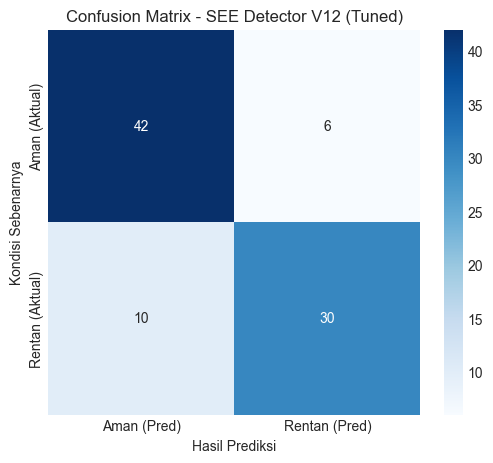

In [13]:
# Plot Confusion Matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Aman (Pred)', 'Rentan (Pred)'], 
            yticklabels=['Aman (Aktual)', 'Rentan (Aktual)'])
plt.title('Confusion Matrix - SEE Detector V12 (Tuned)')
plt.ylabel('Kondisi Sebenarnya')
plt.xlabel('Hasil Prediksi')
plt.show()


## 4. ROC-AUC Curve
Kurva Receiver Operating Characteristic untuk menilai trade-off antara True Positive Rate dan False Positive Rate.

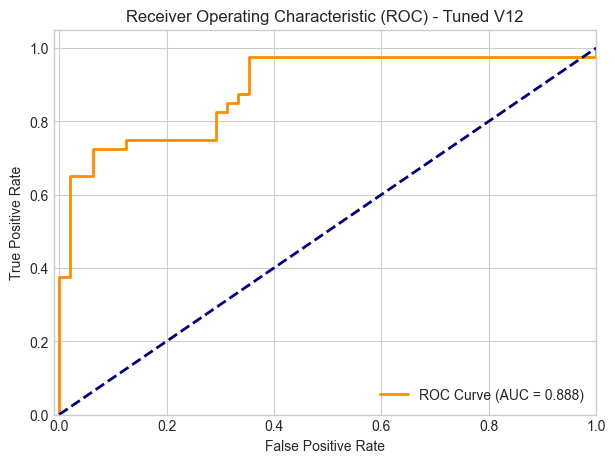

In [14]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Tuned V12')
plt.legend(loc="lower right")
plt.show()


## 5. Feature Importance
Melihat fitur mana yang paling diperhatikan oleh model (Random Forest) saat menentukan apakah ekstensi berbahaya atau tidak.

C:\Users\lernovo\AppData\Local\Temp\ipykernel_41908\2846459846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=importance.head(20), palette='viridis')


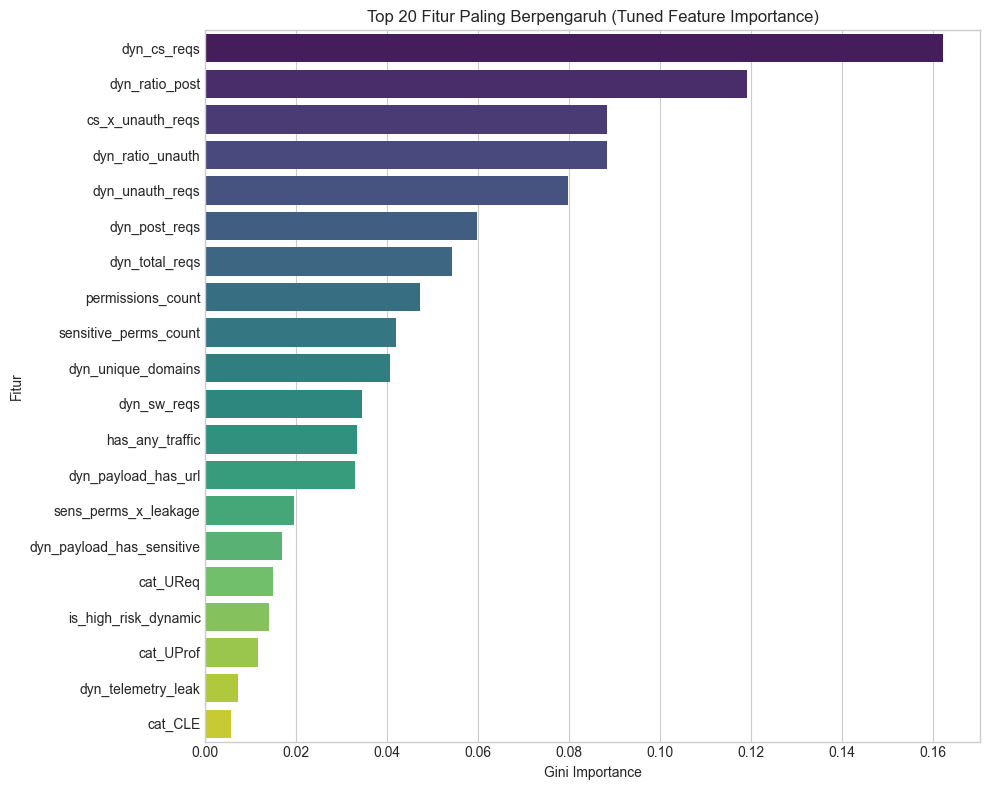

In [15]:
# Gunakan best_rf untuk Feature Importance
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=importance.head(20), palette='viridis')
plt.title('Top 20 Fitur Paling Berpengaruh (Tuned Feature Importance)')
plt.xlabel('Gini Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()
